# 2D Random Walk with Boundary (Box)

Now that we have a basic 2D random walk program , we need to add some critical features. The first is confining the random walker to the inside of a boundary - just like a biomolecule is confined to the inside of a cell by a barrier (the cell wall).

We will start with a very simple 2D boundary - a **box** or **rectangle**. But we want to make our code flexible enough so we can incorporate new boundary shapes: circles, ellipses, crosses, etc- without re-writing the entire program.

**Key questions** about our boundary (box) are:


> 1. **How to describe a box in the program?**
>
> 2. **How to determine if a given point (x,y) is inside the box or outside?**
>
> 3. **What do we do if the random walker attempts to move "outside" of the boundary?**

We will create new python functions which answer each of these questions.




<hr style="border:4px solid blue"> </hr>

## How to describe a box in the program?

**A box can be described in several different ways:**

> By giving the positions of the **corners** of the box, as shown in first figure below

> By giving the **center** position of the box along with three parameters : **width, height, and orientation** (tilt angle)


<img src="./rectangle_level.jpg" width="300" align="left">
<img src="./rectangle_tilted.jpg" width="300" align="center">

To simplify things, we will assume our box is **level** as in the first figure above, so we can ignore the orientation angle of the box. We don't lose much with this simplification.

If the box is **level**, we don't need all of the box's four corners to describe the box. We only need two points; the bottom left corner and the top right corner as we look at the figure. For example, the level box on the left above could be described with a pair of tuples, as shown in the code snippet below :


```
        low_left = (-6,-1)
        top_right = (10, 5)
        box = (low_left, top_right)
```

Recall that tuples are just like lists, but are immutable (can't be changed with indexing). Tuples are widely used in python for storing sets of points or vectors in space, like (x,y) in 2D or (x, y, z) in 3D.


**Setup_box  function:**

It is easier for a user to think about the box in terms of its position (center point) and dimensions (width, height) so we will use those parameters as the input to the function , **setup_box**. Then the function will compute the two box corners,  **low_left**, **top_right**, and return them as a tuple of two tuples.

Below is a python script showing the **setup_up** function , as well as a special draw_box function we will use to draw th box on our random walk plot.




# Exercise with setup_box function

Change the box dimensions and location parameter in the box set up statements in the python script below. Then run the script to see how the box is drawn on a plot. You can also change the box color by modifying  the **edgecolor='b'** inside the **draw_box** function. Some other box color choices: 'r' red, 'y' yellow, 'g' green.


```
        box = setup_box((0.0, 0.0), 40, 40)  # center, width, length of box
        start_loc = (0.0, 0.0)               # Start location for walker
```

Can you see how "setup_box" translates the user's box dimensions (**center, width, height**) to the box corner tuples we will use inside the program?

box = ((-6.0, -1.0), (10.0, 5.0))


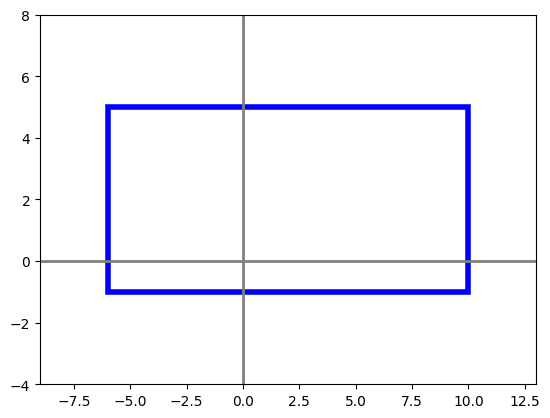

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # Used to draw rectangle


def setup_box(box_loc, width, height):
    """
    Sets shape of rectangle. Returns upper and lower corners
    """
    xloc, yloc = box_loc
    low_left  = (xloc - .5 * width, yloc -.5 * height)
    top_right = (xloc + .5 * width, yloc +.5 * height)
    return (low_left, top_right)

def draw_box(start_loc, box):
    """
    Draw box on graph and set size of graph (xlim,ylim)
    """
    xmin, ymin = box[0]       # low_left
    xmax, ymax = box[1]       # top_right
    plt.gca().add_patch(Rectangle((xmin,ymin), xmax-xmin, ymax-ymin,  fill=False, edgecolor='b',lw=4))
    plt.xlim([xmin-3,xmax+3])
    plt.ylim([ymin-3,ymax+3])

    #  Create bold axis lines through walk starting point
    plt.axvline(start_loc[0], color='grey', lw=2)
    plt.axhline(start_loc[1], color='grey', lw=2)
    return

box  = setup_box((2.0, 2.0), 16, 6)  # center, width, length of box
start_loc   = ( 0.0, 0.0)             # Start lcation for walker
print(f'box = {box}')
draw_box(start_loc, box)

## How do we determine if a point (x, y) is inside the box or outside?

Here we repeat the example of our box description as a tuple of tuples from above:


```
    low_left = (-6,-1)
    top_right = (10, 5)
    box = (low_left, top_right)
```
    
If we had a point (x, y), how would we confirm that this point is inside or outside of the box as described above?

Well, to be inside, we have to have x between -6 and 10, and y between -1, and 5.

In the exercise below, you will complete the **check_inside_box** function which uses this idea. **check_inside_box** should return **True** if the point (xvalue, yvalue) is inside the box, and return **False** if it is outside.

Remember, you will need to **unpack** the box tuple to use the values inside. For example to unpack box to the two corners, we would use a statement like:

```
    low_left, top_right = box
```

or, we could do this:

```
    low_left  = box[0]
    top_right = box[1]
    
```



Then you must unpack these two tuples as well!

## Exercise: Complete the check_inside_box function below and test

In [2]:
def check_inside_box(xvalue, yvalue, box):
    """
    Checks if point (xvalue, yvalue) is inside a rectangle defined by
    tuple: box = (low_left, top_right). Returns True if inside,False if not
    """

####################################################################
#   Your CODE goes HERE to complete this function.
#   Return True if point (xvalue,yvalue) is inside box, otherwise
#     Return False.
#
#   HINT: Note that low_left and top_right are 2-value tuples that
#   locate lower left and upper right corners of box. See setup_box
####################################################################

    low_left, top_right = box
    x_min, y_min = low_left
    x_max, y_max = top_right

    if x_min <= xvalue <= x_max and y_min <= yvalue <= y_max:
        return True
    else:
        return False

    return in_box

box = ((-6,-1), (10, 5))
print(check_inside_box(-5, 3, box) ) # Should return True
print(check_inside_box(-5, 10, box) ) # Should return False

True
False


# What if the random walker tries to move outside of the boundary (box)?

One answer is to "reflect" or "ricochet" the walker back into the box like a cue ball hitting the side of a billiards table. This doesn't work for a couple of reasons:

>  1. We don't know the angle that the walker takes when it hits the side of the box. It could be computed, but we would have to carry along a lot more information about the walker's random move.

>  2. More importantly, molecules inside cells do not act like billiard balls. They have internal structure and may bounce off the cell wall randomly in any direction.

A **better idea**:


> We conduct a "trial" random move for the walker at each time-step. If the "trail" move is inside the box, we make the "trial" into a real move and update the walker's sequence and current position accordingly. If the "trial" move takes the walker outside of the box, we reject it and attempt another random "trial" move. We keep this up until we get a move that is inside the box!



Below , you will change the **random_walk_box** function to include the "trial" moves.  

In the shell **random_walk_box** function provided below, we have included "commented out" lines of code from the original **random_walk2d** function you worked on before.  You will need to uncomment, modify, and expand on these line to complete the function correctly.

Also provided are the **rand_angle** and **check_inside_box** functions that the **random_walk_box** function uses. Do not modify either of these functions.




## Exercise: Complete random_walk_box function

This is one of the harder exercises. Give it a try, but (in this case) definitely take a peek at the solution if you are stuck or having trouble.

In [1]:
import random as random
import numpy as np

def rand_angle():
    """
    Performs unit 2D random step at random angle ( 0 to 2*PI)
    Returns (x,y) co-ordinates of unit step at random angle
     """
    rand_angle = random.uniform(0,2*np.pi)
    xdelta = np.sin(rand_angle)
    ydelta = np.cos(rand_angle)
    return xdelta, ydelta


def check_inside_box(xvalue, yvalue, box):
    """
    Checks if point (xvalue, yvalue) is inside a rectangle defined by
    tuple: box = (low_left, top_right). Returns True if inside,False if not
    """
    xmin, ymin = box[0]  # low left
    xmax, ymax = box[1]  # top right
    if xmin < xvalue < xmax and ymin < yvalue < ymax:
        return True
    else:
        return False


def random_walk_box(num_steps, start_loc, box):
    """ Function conducts 2D random walk inside a box
        Inputs:
          start_loc: tuple with starting (x,y) position of walker
          num_steps: number of actual steps taken not trials
          box:  tuple that describes low_left, top_right corner
        Returns:
          xwalk, ywalk: Sequence of steps for x and y positions
    """

    #initialization steps
    xpos, ypos = start_loc    # Unpack start location tuple
    xwalk = np.zeros(num_steps+1)
    ywalk = np.zeros(num_steps+1)
    xwalk[0] = xpos
    ywalk[0] = ypos

###############################################################################
#   YOUR CODE GOES HERE:
#
#
#      Write function to conduct 2D random walk completely inside the setup box,and
#      starting at the 'start_loc' (see above).
#      Use your function 'check_inside_box' to see if a proposed move is valid.
#      If not valid, propose a new move and check again.
#      Step is counted only if it is inside box. Stop when maximum number of
#      steps is reached.
#      Output will be two arrays called xwalk and ywalk.
#
###############################################################################

    for i in range(num_steps):
      while True:
        dx, dy = rand_angle()
        next_x = xwalk[i] + dx
        next_y = ywalk[i] + dy

        if check_inside_box(next_x, next_y, box):
          xwalk[i + 1] = next_x
          ywalk[i + 1] = next_y
          break

    return xwalk, ywalk

box = ((-6,-1),(10, 5))
start_loc = (0, 0)
num_steps = 1000
xwalk, ywalk =  random_walk_box(num_steps, start_loc, box)
x_last = xwalk[-1]
y_last = ywalk[-1]

print(x_last, y_last, check_inside_box(x_last, y_last, box))  # last point in random should be inside box

9.64598262900244 3.6536066868851984 True


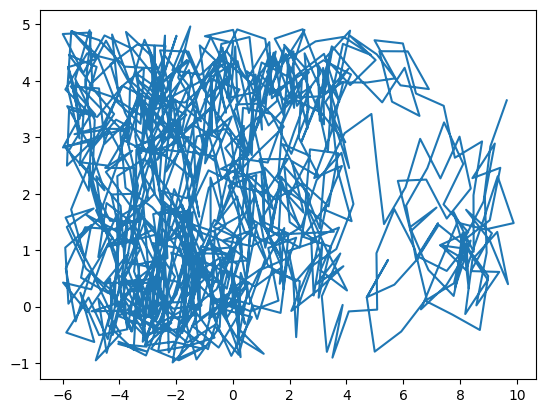

In [4]:
plt.plot(xwalk, ywalk)

<hr style="border:4px solid blue"> </hr>

## Exercise: Putting it all together...

In the cell below, we have included all the functions and logic to perform multiple random walks inside a boundary and to plot the random walks on the same plot.

The code used should look very familiar, since much of it is borrowed from 1D and 2D random walk programs.

Make sure you understand the meaning and purpose of each line in the program. Again, look up unfamiliar commands or methods in the python documentation or programming internet forums(stack exchange) by googling questions. This program is the basis for our next task:

    > Introducing a target inside the boundary for the random walker to find


Once you are sure program is working- it will produce a nice graph - uncomment the the following line at bottom of program to save a copy of the plot on disk:

```
        plt.savefig("rw2d_box1.png")
```


>  Change the file-save name and/or extension ( if you like) and run the program to save a copy of your plot.


## 2D Random Walk with Boundary

Enter number of walks to do (1-5):5


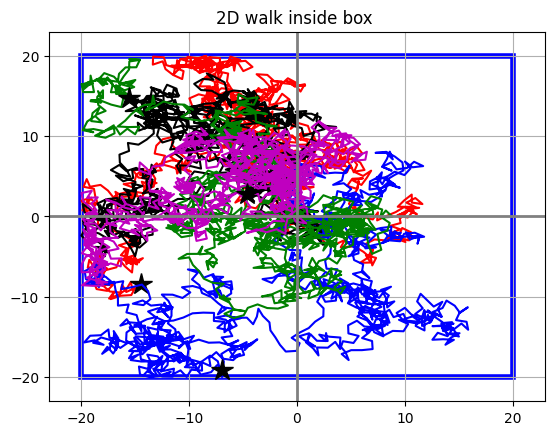

In [6]:
#
#  Executes random walk inside a confining
#  boundary(rectangle).Following parameters can be changed:
#    1- Size and location of box
#    2 -Starting location for random walk
#
import sys
import random as random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # Used to draw rectangle
random.seed(None)        # Seed generator, None => system clock

def rand_angle():
    """
    Performs unit 2D random step at random angle ( 0 to 2*PI)
    Returns (x,y) co-ordinates of unit step at random angle
     """
    rand_angle = random.uniform(0,2*np.pi)
    xdelta = np.sin(rand_angle)
    ydelta = np.cos(rand_angle)
    return xdelta, ydelta

def setup_box( box_loc , width, height):
    """
    Sets shape of rectangle. Returns upper and lower corners
    """
    xloc,yloc = box_loc
    low_left  = (xloc - .5 * width, yloc -.5 * height)
    top_right = (xloc + .5 * width, yloc +.5 * height)
    return (low_left, top_right)


def check_inside_box(xvalue, yvalue, box):
    """
    Checks if point (xvalue, yvalue) is inside a rectangle defined by
    tuple: box = (low_left, top_right). Returns True if inside,False if not
    """
    xmin, ymin = box[0]       # low_left
    xmax, ymax = box[1]       # top_right
    return xmin < xvalue < xmax and ymin < yvalue < ymax

def random_walk_box(num_steps, start_loc, box):
    """ Function conducts 2D random walk inside a box """
#    Start point for walk
    #initialization steps
    xpos, ypos = start_loc    # Unpack start location tuple
    xwalk = np.zeros(num_steps+1)
    ywalk = np.zeros(num_steps+1)
    xwalk[0] = xpos
    ywalk[0] = ypos

    for i in range(num_steps):
        # Create trial move
        xdelta, ydelta = rand_angle()
        xtrial = xpos + xdelta
        ytrial = ypos + ydelta
        # Check if trial move is inside boundary. If so, accept it
        while not check_inside_box(xtrial, ytrial, box):
            xdelta, ydelta = rand_angle()
            xtrial = xpos + xdelta
            ytrial = ypos + ydelta

        xpos = xtrial
        ypos = ytrial

        xwalk[i+1] = xpos
        ywalk[i+1] = ypos


    return xwalk,ywalk

def draw_box(start_loc, box):
    """
    Draw box on graph and set size of graph (xlim,ylim)
    """
    xmin, ymin = box[0]       # low_left
    xmax, ymax = box[1]       # top_right
    plt.gca().add_patch(Rectangle((xmin,ymin), xmax-xmin, ymax-ymin,  fill=False, edgecolor='b',lw=4))
    plt.xlim([xmin-3,xmax+3])
    plt.ylim([ymin-3,ymax+3])

    #  Create bold axis lines through walk starting point
    plt.axvline(start_loc[0], color='grey', lw=2)
    plt.axhline(start_loc[1], color='grey', lw=2)
    return


#   Enter number of walks to plot and check entered value
num_walks = int(input('Enter number of walks to do (1-5):'))
if num_walks <= 0 or num_walks >5:
    print (f'Number of walks selected = {num_walks} - must be between 1 and 5')
    sys.exit(0)


#   Enter number of steps for random walk
num_steps = 1000

#  Set up confining box, starting point for walks
box  = setup_box((0.0, 0.0), 40, 40)
start_loc   = ( 0.0, 0.0)

#  Allows each walk to use a different color/line type on plot
line_type = ['r-','b-','k-','g-','m-']


#  Perform random walk and plot result for each walk
plt.clf()     #  Clear the graph figure
for i in range(num_walks):
    xwalk1, ywalk1 = random_walk_box(num_steps, start_loc,box)
    plt.plot(xwalk1, ywalk1, line_type[i], label = f'walk{i+1}')
    plt.plot(xwalk1[-1],ywalk1[-1], 'k*', ms=16)  # Put large black * to mark end of walk


#  Draw box on graph and display graph
draw_box(start_loc, box)
plt.title('2D walk inside box ' )
plt.grid(True)
#plt.savefig("rw2d_box1.png")
plt.show()

## Challenge Exercise

If you complete this program, try this for a challenge exercise:
    
>  Instead of a confining box, use a circle or even  better, an ellipse to confine the random walker. Create a new program based on program above that uses a confining circle or ellipse to control and plot movement.

>  You will need to look up on the internet how to define and draw a circle or ellipse in the plane and how to determine if a point is inside or outside.